In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(42)

# A tiny 4x4 GridWorld. Start at the top-left, reach the goal at bottom-right,
# and avoid the trap. No external environment package is required.
ROWS, COLS = 4, 4
START = (0, 0)
GOAL = (3, 3)
TRAP = (1, 3)
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)] # up, down, left, right
ACTION_NAMES = ["up", "down", "left", "right"]

Q = np.zeros((ROWS, COLS, len(ACTIONS)), dtype=float)
alpha = 0.15
gamma = 0.95
epsilon = 1.0
min_epsilon = 0.05

In [3]:
def step(state, action):
    r, c = state
    dr, dc = ACTIONS[action]
    nr = min(max(r + dr, 0), ROWS - 1)
    nc = min(max(c + dc, 0), COLS - 1)
    next_state = (nr, nc)
    if next_state == GOAL:
        return next_state, 1.0, True
    if next_state == TRAP:
        return next_state, -1.0, True
    return next_state, -0.04, False

In [4]:
def choose_action(state, explore=True):
    if explore and rng.random() < epsilon:
        return int(rng.integers(len(ACTIONS)))
    r, c = state
    return int(np.argmax(Q[r, c]))

In [5]:
training_returns = []

for episode in range(5000):
    state = START
    done = False
    
    episode_return = 0.0
    for _ in range(100):
        action = choose_action(state, explore=True)
        next_state, reward, done = step(state, action)
        episode_return += reward
        
        r, c = state
        nr, nc = next_state
        backup_value = reward if done else reward + gamma * np.max(Q[nr, nc])
        Q[r, c, action] += alpha * (backup_value - Q[r, c, action])
        state = next_state
        
        if done:
            break
            
    training_returns.append(episode_return)
    epsilon = max(min_epsilon, epsilon * 0.9985)

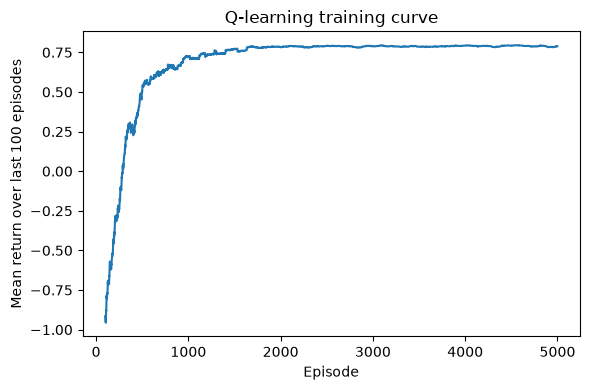

In [6]:
window = 100
moving = np.convolve(training_returns, np.ones(window) / window, mode="valid")
plt.figure(figsize=(6, 4))
plt.plot(np.arange(window - 1, len(training_returns)), moving)
plt.xlabel("Episode")
plt.ylabel("Mean return over last 100 episodes")
plt.title("Q-learning training curve")
plt.tight_layout()
plt.show()

In [8]:
# Evaluate the learned greedy policy.
successes = 0
returns = []
for _ in range(200):
    state = START
    total_reward = 0.0
    for _ in range(100):
        action = choose_action(state, explore=False)
        state, reward, done = step(state, action)
        total_reward += reward
        if done:
            successes += int(state == GOAL)
            break
    returns.append(total_reward)
        
print("success rate:", successes / 200)
print("mean return:", round(float(np.mean(returns)), 3))
print("learned action at start:", ACTION_NAMES[choose_action(START, explore=False)])

success rate: 1.0
mean return: 0.8
learned action at start: down
